# Maximum Likelihood Estimation (MLE) 

In this notebook, we **demystify MLE** using simple, worked-out examples, and visualizations.

We also show **mathematical equations** and apply MLE to a **drug discovery scenario**, making this practical .

## What is MLE?
Maximum Likelihood Estimation is a method for finding the **most likely explanation** for some data.

**Example**: Given flipping a coin 10 times and seeing 7 heads. What is the probability of heads? MLE says: _Find the probability that makes these 7 heads most likely._

**analogy**: MLE is like being a detective. You have clues (data), and you try to guess the story (parameters) that most likely produced those clues.

## The Math Behind MLE

For a coin flip (Bernoulli trial), the likelihood function is:

$$ L(p) = p^k (1 - p)^{n - k} $$

where:
- $p$ = probability of heads
- $k$ = number of heads
- $n$ = total flips

**We maximize this likelihood** to find the best $p$. Often we maximize the **log-likelihood** (easier math):

$$ \log L(p) = k \log p + (n - k) \log (1 - p) $$

## Example 1: Estimating a Coin's Bias

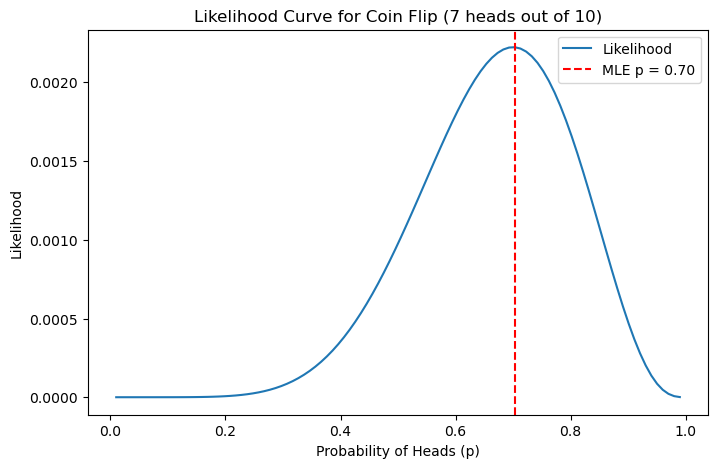

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate 10 flips: 7 heads
n = 10
k = 7
p_values = np.linspace(0.01, 0.99, 100)
likelihoods = (p_values ** k) * ((1 - p_values) ** (n - k))

plt.figure(figsize=(8,5))
plt.plot(p_values, likelihoods, label='Likelihood')
plt.title('Likelihood Curve for Coin Flip (7 heads out of 10)')
plt.xlabel('Probability of Heads (p)')
plt.ylabel('Likelihood')
plt.axvline(p_values[np.argmax(likelihoods)], color='red', linestyle='--', label=f'MLE p = {p_values[np.argmax(likelihoods)]:.2f}')
plt.legend()
plt.show()

### Takeaway
The red dashed line shows the **MLE estimate**. For 7 heads out of 10 flips, the best guess is around 0.7.

## 🔬 Example 2: Estimating Drug Potency (Normal Distribution)
We simulate IC50 (drug potency) measurements and estimate the true mean potency.

In [ ]:
np.random.seed(0)
true_mu = 50
true_sigma = 5
sample = np.random.normal(true_mu, true_sigma, 30)

# Grid of mean values to evaluate
mu_values = np.linspace(40, 60, 100)
likelihoods = [np.prod(norm.pdf(sample, loc=mu, scale=true_sigma)) for mu in mu_values]

plt.figure(figsize=(8,5))
plt.plot(mu_values, likelihoods)
plt.axvline(sample.mean(), color='red', linestyle='--', label=f'MLE Mean = {sample.mean():.2f}')
plt.title('Likelihood Curve for Drug Potency (IC50)')
plt.xlabel('Mean Potency (μ)')
plt.ylabel('Likelihood')
plt.legend()
plt.show()

### What We See
The MLE picks the mean that **maximizes likelihood**—typically close to the sample mean for normal distributions.

## Drug Discovery Application
In drug discovery, scientists measure things like **IC50** or **binding affinities** across compounds. MLE helps estimate the **true potency** from noisy experiments.

**Why it matters**: More accurate estimates = better decisions about which drug to advance.

### Real-World Scenario
Suppose you test a new inhibitor 30 times and get noisy IC50 results. MLE lets you estimate the **true potency (mean μ)** and model uncertainty, guiding next steps.

## Math Recap for Drug Discovery
For normal data:

$$ L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left( - \frac{(x_i - \mu)^2}{2 \sigma^2} \right) $$

MLE chooses $\hat{\mu}$ and $\hat{\sigma}$ that maximize this likelihood.

For fixed $\sigma$, $\hat{\mu}$ = **sample mean**.

## Conclusion
MLE finds the parameter values that **best explain your data**. With visuals and math, we’ve seen how MLE works for:
- Coins (Bernoulli)
- Drug potency (Normal)

**MLE = smarter, data-driven decisions! **